# Оценка ИИ-агентов: датасеты, judges и метрики

На этом занятии вы:

1. Разделите показатели эффективности, результативности и качества агентной системы.
2. Соберёте небольшой датасет и запустите воспроизводимый бенчмарк.
3. Реализуете подход LLM-as-a-judge и обсудите его ограничения.
4. Рассчитаете метрики результата, траектории, инструментов, памяти и безопасности.
5. Познакомитесь с современными бенчмарками для tool-use, терминальных и computer-use агентов.

# Введение

Обычную языковую модель часто оценивают по одному ответу: совпал ли он с эталоном, содержит ли нужный факт, насколько хорошо написан текст. Агент же устроен сложнее: он получает цель, планирует действия, вызывает инструменты, читает их результаты, использует память и решает, когда остановиться. Финальный ответ или результат может быть получен как надёжной короткой траекторией, так и почти случайно после лишних вызовов инструментов, ошибок и небезопасных действий. На этом занятии мы начнем говорить про оценку LLM-агентов, рассмотрим основные подходы и метрики и познакомимся с ключевыми современными агентными бенчмарками.


# Установка зависимостей

Установите нужные зависимости через `pip` и импортируйте модули.

Вам понадобятся:
- `langchain-gigachat` — для LangChain обертки GigaChat API;
- `pydantic` — для контролируемой генерации и инструментов;
- `langgraph` — для LangGraph агентов и мультиагентных систем.

Перед запуском ноутбука убедитесь, что у вас установлены нужные версии библиотек.

In [ ]:
%%capture
%pip install pydantic==2.11.7 langgraph==0.5.3 langchain-gigachat==0.5.1

In [ ]:
from langchain_gigachat import GigaChat
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

from pydantic import BaseModel, Field
from typing import List, Annotated, Optional, Dict, Any
from typing_extensions import TypedDict
from dataclasses import dataclass

import requests
import json
import random

from IPython.display import Image, display

In [ ]:
import getpass




Вставьте ваш ключ авторизации `gigachat`:

In [ ]:
GIGACHAT_KEY = getpass.getpass()

Подключите модель и проверьте работоспособность

In [ ]:
gigachat_llm = GigaChat(
    credentials = GIGACHAT_KEY,
    scope="GIGACHAT_API_B2B",
    model="GigaChat-2-Max",
    verify_ssl_certs=False,
    timeout=120,
)

In [ ]:
print(gigachat_llm.invoke("Привет, кто ты?").content)

# Как и зачем оценивать LLM-агентов


В этом разделе мы поговорим про общие подходы к оценке LLM-агентов.

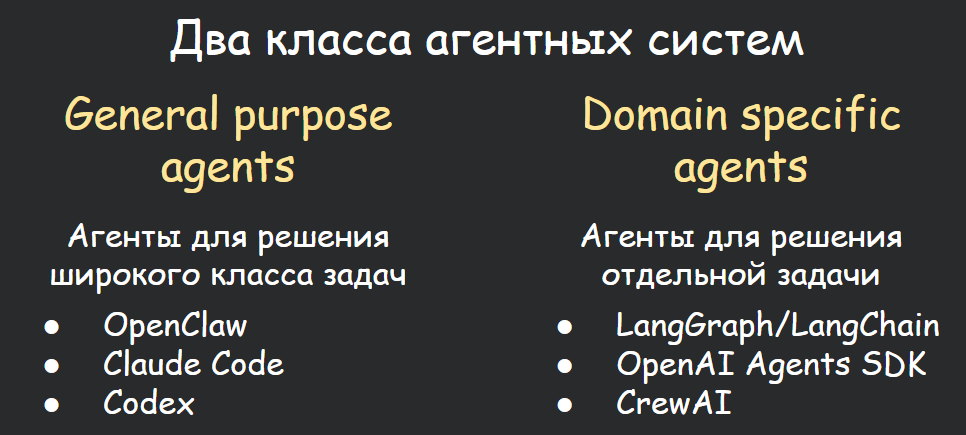

Прежде чем говорить про оценку агентов, важно помнить про два класса систем, которые являются агентами
- **General purpose агенты** нужны для решения широкого класса задач (написание кода, веб-поиск, работа с документами, рисование презентаций и тд). Как правило, они имеют пользовательский интерфейс и возможности для кастомизации.
- **Domain specific агенты** разрабатываются для решения отдельной, как правило узкой и предметно специфичной задачи. Для их создания используют фреймворки вроде LangChain/LangGraph и OpenAI Agents SDK.

Вообще говоря, для этих классов агентов применяются разные методы и метрики оценки (хотя они пересекаются, конечно). В этом уроке мы поговорим про общие механизмы оценки, в том числе для general-purpose агентов, а в следующие 3 больше сосредоточимся на оценке domain specific агентов.

## Эффективность vs качество



Когда мы говорим про оценку LLM-агентов, то обычно подразумеваем 2 класса показателей
- Метрики **эффективности** показывают, какое количество ресурсов потребовалось агенту для выполнения задачи. К ним относятся время генерации ответа, число потраченных токенов, стоимость вызовов модели, количество обращений к инструментам, загрузка CPU/GPU и тд. Эффективный агент достигает цели быстрее и дешевле, но низкая стоимость сама по себе не означает, что задача решена правильно.

- Метрики **качества** показывают, насколько результат и процесс соответствуют требованиям: доля успешно завершённых задач, точность фактов, корректность параметров инструментов, соблюдение политики безопасности, полнота ответа и тд. На их основе можно сделать вывод о том, насколько хорошо и качественно работает LLM-агент.

Можно сформулировать так:
- Метрика эффективности: "Сколько ресурсов потребляет LLM-агент?"
- Метрика качества: "Насколько хорошо LLM-агент решает поставленные задачи?"

Эти группы следует читать совместно. Например, агент A может иметь Success Rate 90% при высокой задержке, а агент B — 82% при вдвое меньшей стоимости. Окончательный выбор агента зависит от проекта и ограничений.

В этом курсе мы сосредоточимся на **метриках качества**.

## Что оценивать в агентной системе?

У агентной системы удобно выделить три уровня оценки.

> Базовая LLM

Здесь проверяют способности самой модели без обвязки (или почти без нее). Оцениваются знания модели, качество ее рассуждений, умение решать классические NLP задачи и работать с длинным контекстом.

Примеры бенчмарков:

- **MMLU / MMLU-Pro** — знания и решение тестовых задач из разных дисциплин.
- **GPQA** — сложные вопросы уровня аспирантуры; полезен для проверки глубокого предметного знания.
- **GSM8K** — школьные математические задачи с многошаговым решением.
- **HumanEval** — генерация небольших функций по спецификации и проверка тестами.
- **TruthfulQA** — устойчивость к распространённым заблуждениям и ложным предпосылкам.


> LLM harness

Harness - это программная обвязка вокруг модели. Она определяет доступные инструменты, формат сообщений, состояние и цикл работы агента.

Здесь проверяются качество промптов для агента, как хорошо harness работает с skills и инструментами, как сжимает контекст и какие дает механизмы для обработки ошибок.

Примеры бенчмарков:

- **BFCL** — выбор функций и корректность аргументов, включая многошаговые сценарии.
- **τ-bench** — диалог агента с пользователем и API в соответствии с правилами предметной области.
- **ToolBench** — выбор и композиция большого числа реальных API.
- **AgentBench** — работа языковых агентов в нескольких интерактивных средах.

> Агент как программная система

Здесь применяются обычные практики software engineering и эксплуатации.



Важно понимать, что нельзя переносить результат одного уровня на другой автоматически: сильная LLM может показывать слабый результат из-за плохого промпта или инструмента, а хороший harness способен частично компенсировать ограничения модели.

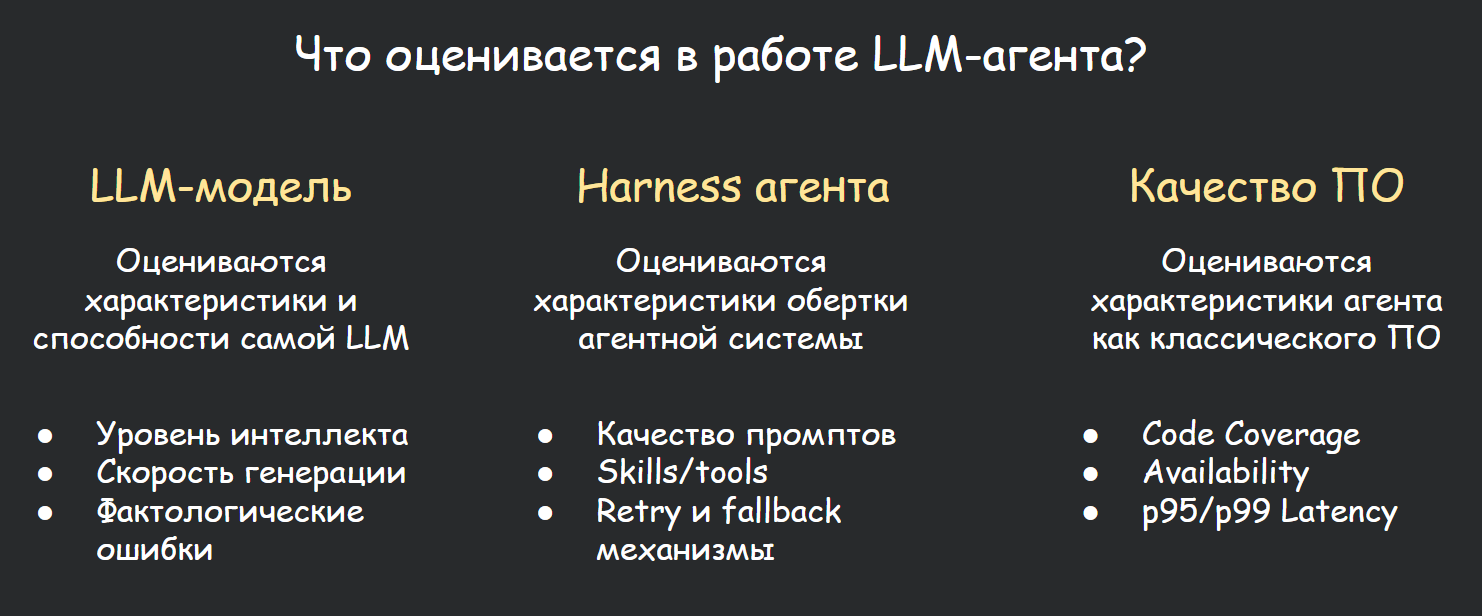

В рамках курса мы сосредоточимся на оценке качества **LLM harness** и немного самой **LLM**.

## Способы получения оценки


Есть разные способы **получить оценку качества LLM агента**, их можно собрать в такие группы
- **Автоматические метрики**: система оценивает себя сама, без внешнего участия; как правило, подразумевается наличие некоторой формализуемой среды (пример — агент для игры в тетрис).
- **Метрики из датасетов**: вручную готовится набор задач с правильными ответами/примерами поведения, затем проверяется, как система с ними справляется (пример — агент для решения математических задач).
- **LLM-as-a-judge**: полуавтоматический режим, при котором LLM оценивает качество работы другой LLM, LLM-агента или мультиагентной системы (пример — агент для написания художественных книг).
- **Ручная разметка** — подход, при котором ответы MAS размечаются вручную людьми (пример — агент для персонажной коммуникации).
- **Экспертная разметка** — подход, при котором ответы MAS размечаются вручную экспертами в своей области (пример — агент для решения Humanity Last Exam).

Каждый следующий метод более универсален и объективен, но более дорогой и долгий, чем предыдущий.

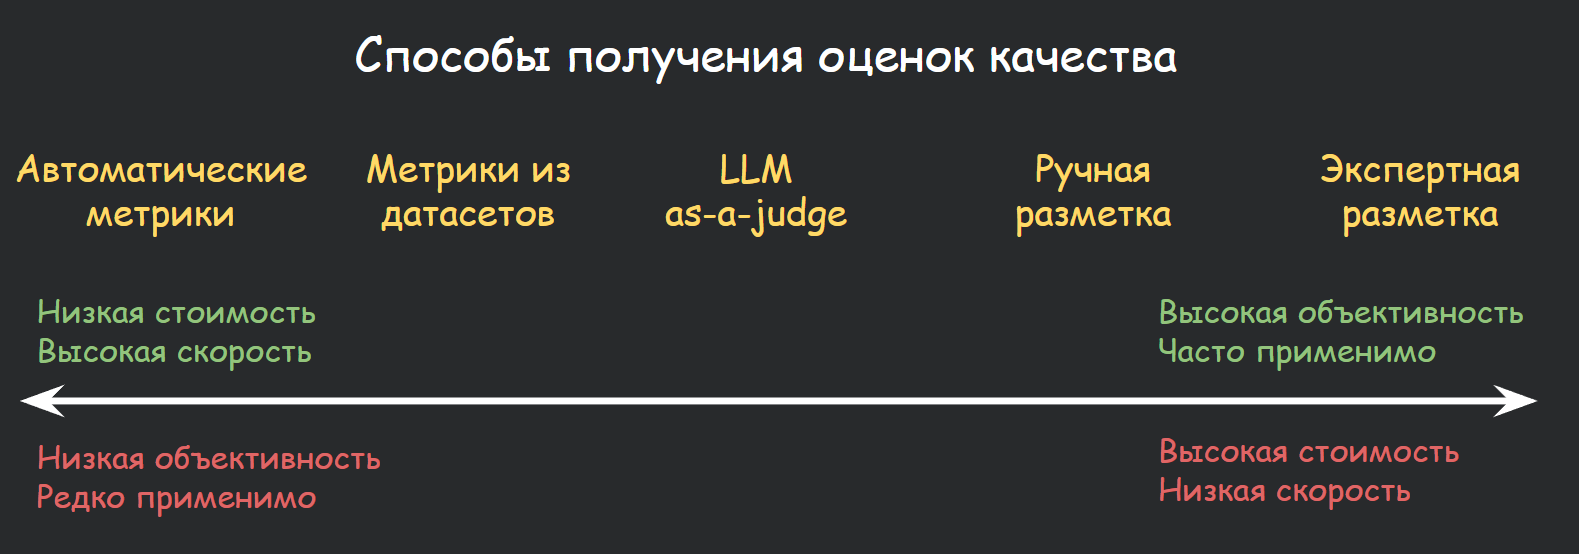

На этом курсе мы остановимся на **датасетах и LLM-as-judge (или просто judge)**.

### Автоматические оценки



**Автоматическая оценка** вычисляется непосредственно из наблюдаемого состояния среды или формального правила, без разметки человеком и без внешней LLM (например, счёт в игре или доля пройденных тестов после коммита). Такой сигнал дешёв, воспроизводим и хорошо масштабируется, но он оценивает только то, что легко формализовать и замерить. К тому же, плохо выбранная награда может стимулировать reward hacking: агент максимизирует число очков, не выполняя реальную цель пользователя.

Рассмотрим пример агента, который играет в упрощенную змейку:
- задача агента — передвигаться по полю так, чтобы не возвращаться в те ячейки, в которых он уже был;
- награда агента — количество ячеек, в которых он успел побывать.

> В демонстративных целях ходы агента случайные.

In [ ]:
class GameEnvironment:
    def __init__(self):
        self.position = (0, 0)
        self.history = [self.position]
        self.game_over = False

    def step(self, direction):
        new_position = (0, 0)
        if direction == 'up':
            new_position = (self.position[0], self.position[1] + 1)
        elif direction == 'down':
            new_position = (self.position[0], self.position[1] - 1)
        elif direction == 'left':
            new_position = (self.position[0] - 1, self.position[1])
        elif direction == 'right':
            new_position = (self.position[0] + 1, self.position[1])
        self.position = new_position
        if self.position in self.history:
            self.game_over = True
        self.history.append(self.position)

    def get_score(self):
        return len(self.history)

In [ ]:
class AgentState(TypedDict):
    game_env: GameEnvironment
    probs: list[float]
    num_of_steps: int
    max_num_of_steps: int
    finish: bool

def snake_step(state: AgentState):
    probs = state["probs"]
    env = state["game_env"]

    direction = random.choices(['up', 'down', 'left', 'right'], probs)[0]
    print(f"Going {direction}")
    env.step(direction)

    if env.game_over or state["num_of_steps"] == state["max_num_of_steps"]-1:
        return {"finish": True, "num_of_steps": state["num_of_steps"]+1}
    else:
        return {"num_of_steps": state["num_of_steps"]+1}

In [ ]:
builder = StateGraph(AgentState)

builder.add_node("snake", snake_step)

builder.add_edge(START, "snake")
builder.add_conditional_edges(
    "snake",
    lambda state: "END" if state["finish"] else "snake",
    {"snake": "snake", "END": END}
)

graph = builder.compile()

In [ ]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [ ]:
env = GameEnvironment()
initial_state = {
    "game_env": env,
    "probs": [1, 1, 1, 1],
    "num_of_steps": 0,
    "max_num_of_steps": 50,
    "finish": False
}

final_state = graph.invoke(initial_state)

In [ ]:
reward = final_state["num_of_steps"]
print("Agent reward:", reward)

### Датасеты и бенчмарки

**Датасет для оценки агента** - это список запросов/задач и правильных ответов/действий агента. Такой ответ/действие еще называют **golden answer/reference**. Для каждого примера задачи полезно хранить входные данные, ожидаемый результат или проверяемое состояние, допустимые варианты, категорию сложности, ограничения и метаданные среды.

- **Ручные датасеты** создают разметчики, эксперты или разработчики. Они обычно точнее отражают реальные риски, но дороги и растут медленно.
- **Синтетические датасеты** генерирует модель по запросу, шаблону или онтологии. Синтетические записи необходимо фильтровать, дедуплицировать и выборочно проверять человеком, но они дешевле и удобнее.



Ниже мы реализуем простого агента, который отвечает только на вопросы из заявленных категорий. Отдельно мы напишем датасет для проверки качества его работы. Две строки датасета намеренно выходят за границы возможностей агента, поэтому ожидается высокая, но не стопроцентная доля успеха.

In [ ]:
class QAState(TypedDict):
    question: str
    category: str
    answer: str

def answer_question(state: QAState):
    supported_categories = {"география", "математика", "естествознание"}
    if state["category"] not in supported_categories:
        return {"answer": "Категория не поддерживается"}

    prompt = (
        "Ответь на вопрос по-русски одной короткой фразой. "
        "Не добавляй вступление и объяснение.\n"
        f"Вопрос: {state['question']}"
    )
    answer = gigachat_llm.invoke(prompt).content.strip()
    return {"answer": answer}

In [ ]:
qa_builder = StateGraph(QAState)

qa_builder.add_node("answer", answer_question)
qa_builder.add_edge(START, "answer")
qa_builder.add_edge("answer", END)

qa_agent = qa_builder.compile()

In [ ]:
qa_dataset = [
    {"question": "Столица Франции?", "category": "география", "expected": ["париж"]},
    {"question": "Столица Австралии?", "category": "география", "expected": ["канберра"]},
    {"question": "На каком материке находится Египет?", "category": "география", "expected": ["африк"]},
    {"question": "Сколько будет 7 умножить на 8?", "category": "математика", "expected": ["56"]},
    {"question": "Чему равен квадрат числа 12?", "category": "математика", "expected": ["144"]},
    {"question": "Сколько градусов в прямом угле?", "category": "математика", "expected": ["90"]},
    {"question": "Как называется спутник Земли?", "category": "естествознание", "expected": ["луна"]},
    {"question": "Какой газ растения поглощают при фотосинтезе?", "category": "естествознание", "expected": ["углекисл"]},
    {"question": "При какой температуре по Цельсию замерзает вода?", "category": "естествознание", "expected": ["0"]},
    {"question": "Какую планету называют Красной?", "category": "естествознание", "expected": ["марс"]},
    {"question": "Кто написал «Капитанскую дочку»?", "category": "литература", "expected": ["пушкин"]},
    {"question": "В каком году началась Отечественная война 1812 года?", "category": "история", "expected": ["1812"]},
]

def contains_expected(answer, expected_parts):
    normalized = answer.lower().replace("ё", "е")
    return all(part.lower().replace("ё", "е") in normalized for part in expected_parts)

len(qa_dataset)

In [ ]:
qa_results = []

for example in qa_dataset:
    result = qa_agent.invoke({
        "question": example["question"],
        "category": example["category"],
        "answer": "",
    })
    passed = contains_expected(result["answer"], example["expected"])
    qa_results.append({**example, "answer": result["answer"], "passed": passed})

for row in qa_results:
    print("ok" if row["passed"] else "no", row["question"], "->", row["answer"])

benchmark_accuracy = sum(row["passed"] for row in qa_results) / len(qa_results)
print(f"\nSuccess rate: {benchmark_accuracy:.1%}")

Более подробно вопрос составления и использования датасетов для замера качества LLM-агентов мы рассмотрим на следующем уроке.

### Judges

**LLM-as-a-judge** - подход, в котором языковая модель получает ответ оцениваемой системы, критерии и, при наличии, эталон (golden answer), а затем возвращает оценку и обоснование.

Judge удобен для открытых задач - эссе, диалогов, резюме или стихотворений, где точное совпадение строк ничего не говорит о качестве. Один судья может оценить тысячи ответов значительно дешевле команды разметчиков.

При этом judge не является объективным. На оценку влияют порядок вариантов, длина и стиль ответа, формулировка правил и даже склонность судьи предпочитать собственные ответы. Поэтому критерии делают наблюдаемыми, используют структурированный формат, перемешивают порядок парных ответов, калибруют судью на человеческой разметке и периодически проверяют согласие экспертов.

Более подробно мы поговорим об этом в 11 и 12 уроках.

Ниже мы построим агента для генераций стихотворений, а затем отдельного судью (judge). Итоговая оценка будет находиться в диапазоне от 0 до 10.

In [ ]:
class PoemState(TypedDict):
    topic: str
    poem: str

def generate_poem(state: PoemState):
    prompt = (
        "Напиши на русском языке короткое стихотворение из 4–8 строк. "
        "Сохраняй тему, образность и связность. Не добавляй комментарии.\n"
        f"Тема: {state['topic']}"
    )
    return {"poem": gigachat_llm.invoke(prompt, temperature=0.9).content.strip()}

In [ ]:
poem_builder = StateGraph(PoemState)

poem_builder.add_node("poet", generate_poem)
poem_builder.add_edge(START, "poet")
poem_builder.add_edge("poet", END)

poem_agent = poem_builder.compile()

> Обратите внимание: ниже мы используем метод `with_structured_output()` для контролируемой генерации в GigaChat.

In [ ]:
class PoemEvaluation(BaseModel):
    """Оценка стихотворения"""
    score: int
    justification: str


def judge_poem(topic: str, poem: str) -> PoemEvaluation:
    prompt = f"""
Ты — строгий преподаватель литературы. Оцени стихотворение по шкале 1–10.
Критерии: соответствие теме, образность, связность и язык, оригинальность.
Верни только JSON вида:
{{"score": int, "justification": "краткое объяснение"}}

Тема: {topic}
Стихотворение:
{poem}
"""
    obj = gigachat_llm.with_structured_output(PoemEvaluation).invoke(prompt)
    return obj

poem_result = poem_agent.invoke({"topic": "Первый снег в университетском дворе", "poem": ""})
poem_evaluation = judge_poem(poem_result["topic"], poem_result["poem"])

print(poem_result["poem"])
print(f"\nОценка: {poem_evaluation.score}/10")
print("Обоснование:", poem_evaluation.justification)

# Метрики работы LLM-агента






В этом разделе мы рассмотрим основные метрики для измерения качества агентных систем.

## Метрики результативности


**Метрики результативности** проверяют, достигнута ли цель, поставленная перед агентом.

- **Success Rate** - доля запусков, в которых выполнены все критерии успеха: `успешные запуски / все запуски`.
- **Error Rate** - доля запусков с ошибкой. Следует заранее определить, что считать ошибкой: исключение, неверный ответ, нарушение политики или тайм-аут. Error Rate не всегда равен `1 − Success Rate`, если существуют частично выполненные задачи.
- **Score** - числовая оценка, показывающая, насколько хорошо работает агент.
- **Task Completion Rate** - доля завершённых задач, включая частичное выполнение по чек-листу. Например, выполнение трёх из четырёх обязательных шагов даёт 0,75.
- **Accuracy** - доля правильных предсказаний или полей среди всех проверенных. Она удобна для классификации и QA, но может скрывать дисбаланс классов; тогда дополнительно нужны precision, recall и F1.

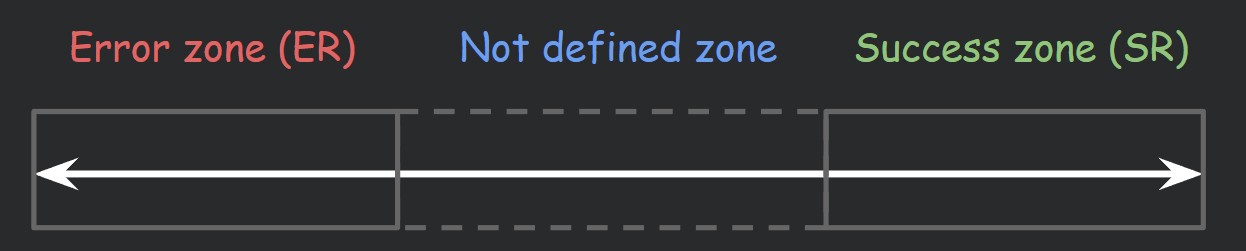

Следующий агент обрабатывает поддерживаемые текстовые операции, а GigaChat формирует понятное объяснение. Один сценарий специально не поддерживается, поэтому Success Rate детерминированно находится строго между 0 и 1.

In [ ]:
class OperationState(TypedDict):
    operation: str
    instruction: str
    answer: str


class OperationJudgement(BaseModel):
    """Оценка ответа"""
    passed: bool
    score: int
    reason: str


def perform_operation(state: OperationState):
    supported_operations = {"uppercase", "length", "reverse"}

    if state["operation"] not in supported_operations:
        return {
            "answer": (
                "Я умею только переводить строку в верхний регистр, "
                "считать символы и разворачивать строку."
            )
        }

    response = gigachat_llm.invoke([
        SystemMessage(content=(
            "Ты агент для трёх операций над строками: uppercase, length и reverse. "
            "Выполни инструкцию точно. Можно кратко объяснить действие, "
            "поэтому ответ не обязан дословно совпадать с эталоном."
        )),
        HumanMessage(content=state["instruction"]),
    ])
    return {"answer": response.content.strip()}

In [ ]:
operation_builder = StateGraph(OperationState)

operation_builder.add_node("perform", perform_operation)
operation_builder.add_edge(START, "perform")
operation_builder.add_edge("perform", END)

operation_agent = operation_builder.compile()

In [ ]:
def judge_operation(
    instruction: str,
    expected: str,
    criterion: str,
    agent_answer: str,
) -> OperationJudgement:
    prompt = f"""
Ты — независимый судья качества LLM-агента.
Определи, выполнена ли инструкция по указанному критерию.

Правила:
- оценивай смысл, а не точное совпадение строк;
- дополнительное краткое объяснение не является ошибкой;
- неверное значение, отказ или отсутствие результата означает passed=false;
- score: 0 — задача не выполнена, 10 — выполнена полностью;
- верни только JSON вида
{{"passed": true/false, "score": int, "reason": "краткое обоснование"}}.

Инструкция: {instruction}
Эталонный результат: {expected}
Критерий успеха: {criterion}
Ответ агента: {agent_answer}
"""
    judgement = gigachat_llm.with_structured_output(OperationJudgement).invoke(prompt)
    return judgement

In [ ]:
operation_builder = StateGraph(OperationState)

operation_builder.add_node("perform", perform_operation)
operation_builder.add_edge(START, "perform")
operation_builder.add_edge("perform", END)

operation_agent = operation_builder.compile()

In [ ]:
operation_dataset = [
    {
        "operation": "uppercase",
        "instruction": "Переведи слово «агент» в верхний регистр.",
        "expected": "АГЕНТ",
        "criterion": "В ответе присутствует строка «АГЕНТ» без изменения букв.",
    },
    {
        "operation": "length",
        "instruction": "Посчитай количество символов в слове «метрика».",
        "expected": "7",
        "criterion": "Названо число 7.",
    },
    {
        "operation": "reverse",
        "instruction": "Разверни строку «данные» задом наперёд.",
        "expected": "еыннад",
        "criterion": "В ответе присутствует строка «еыннад».",
    },
    {
        "operation": "uppercase",
        "instruction": "Переведи строку «LLM agent» в верхний регистр.",
        "expected": "LLM AGENT",
        "criterion": "Обе части строки записаны в верхнем регистре.",
    },
    {
        "operation": "translate",
        "instruction": "Переведи слово «качество» на английский язык.",
        "expected": "quality",
        "criterion": "Дан английский перевод «quality».",
    },
]

In [ ]:
operation_results = []

for example in operation_dataset:
    state = operation_agent.invoke({
        "operation": example["operation"],
        "instruction": example["instruction"],
        "answer": "",
    })

    judgement = judge_operation(
        instruction=example["instruction"],
        expected=example["expected"],
        criterion=example["criterion"],
        agent_answer=state["answer"],
    )

    operation_results.append({
        **example,
        "agent_answer": state["answer"],
        "passed": judgement.passed,
        "score": judgement.score,
        "judge_reason": judgement.reason,
    })

    print(example["instruction"])
    print("Ответ агента:", state["answer"])
    print(
        f"Judge: {'успех' if judgement.passed else 'ошибка'}, "
        f"{judgement.score}/10 — {judgement.reason}\n"
    )

success_rate = (
    sum(result["passed"] for result in operation_results)
    / len(operation_results)
)
mean_judge_score = (
    sum(result["score"] for result in operation_results)
    / len(operation_results)
)

print(
    f"Success Rate = "
    f"{sum(result['passed'] for result in operation_results)}"
    f"/{len(operation_results)} = {success_rate:.2f}"
)

## Метрики качества процесса


Метрики процесса оценивают не только финальный результат работы агента, но и сам процесс его получения.

- **PRM (Process Reward Model)** - модель, которая присваивает награду отдельным шагам рассуждения или действиям. Она помогает локализовать первое неверное или небезопасное действие агента.  
- **Trajectory Efficiency** сравнивает фактическую траекторию с некоторым эталоном. Простой вариант: `минимально необходимое число шагов / фактическое число шагов`, ограниченное единицей.
- **Number of Steps** - число шагов модели, переходов графа или вызовов инструментов. Слишком большое значение может означать зацикливание; слишком малое — преждевременную остановку.

Короткая траектория не обязательно лучше, ведь дополнительная проверка может повысить надёжность. Поэтому процессные метрики анализируют вместе с Success Rate и типом задачи.

Агент ниже генерирует нумерованные шаги решения, а LLM-судья оценивает каждый шаг отдельно.

In [ ]:
class ReasoningState(TypedDict):
    problem: str
    steps: list[str]


class ReasoningTrace(BaseModel):
    """Шаги рассуждений для получения ответа"""
    reasoning_steps: list[str]


def generate_solution_steps(state: ReasoningState):
    prompt = (
        "Реши задачу через 3–7 кратких проверяемых шагов. "
        "Каждая строка должна содержать один шаг; не раскрывай скрытые рассуждения, "
        "показывай только вычисления и утверждения, которые можно проверить.\n"
        f"Задача: {state['problem']}"
    )
    lines = gigachat_llm.with_structured_output(ReasoningTrace).invoke(prompt)
    steps = lines.reasoning_steps
    return {"steps": steps}

In [ ]:
reasoning_builder = StateGraph(ReasoningState)

reasoning_builder.add_node("solve", generate_solution_steps)
reasoning_builder.add_edge(START, "solve")
reasoning_builder.add_edge("solve", END)

reasoning_agent = reasoning_builder.compile()

In [ ]:
class StepEvaluation(BaseModel):
    """Оценка шага"""
    score: int
    comment: str


def judge_reasoning_step(problem: str, previous_steps: list[str], step: str):
    prompt = f"""
Оцени текущий шаг решения:
- 0 — неверен,
- 1 — частично верен,
- 2 — верен и уместен.
Верни только JSON:
{{"score": int, "comment": "краткое объяснение"}}

Задача: {problem}
Предыдущие шаги: {previous_steps}
Текущий шаг: {step}
"""
    obj = gigachat_llm.with_structured_output(StepEvaluation).invoke(prompt)
    return obj

In [ ]:
reasoning_run = reasoning_agent.invoke({
    "problem": "Сколько простых делителей у числа 26473984697160?",
    "steps": [],
})

step_scores = []

for index, step in enumerate(reasoning_run["steps"]):
    evaluation = judge_reasoning_step(
        reasoning_run["problem"],
        reasoning_run["steps"][:index],
        step,
    )
    step_scores.append(evaluation.score)
    print(f"{index + 1}. {step}\n   PRM: {evaluation.score}/2 — {evaluation.comment}")

print("Средняя оценка шага:", sum(step_scores) / len(step_scores) / 2)

In [ ]:
hard_reasoning_problem = \
"""
Six people, Anna, Boris, Chen, Diana, Erik, and Fatima, must be arranged in a line from position 1 to position 6.
Anna must appear before Diana. Boris cannot be adjacent to Chen. If Erik appears before Anna, then Fatima must be immediately after Diana.
Chen must be somewhere before Fatima. Diana cannot be in position 6. Exactly one of Boris and Erik must appear before Anna. Find one valid arrangement.
Then determine whether your arrangement is the only possible one; if it is not, list all valid arrangements.
"""

In [ ]:
reasoning_run = reasoning_agent.invoke({
    "problem": hard_reasoning_problem,
    "steps": [],
})

step_scores = []

for index, step in enumerate(reasoning_run["steps"]):
    evaluation = judge_reasoning_step(
        reasoning_run["problem"],
        reasoning_run["steps"][:index],
        step,
    )
    step_scores.append(evaluation.score)
    print(f"{index + 1}. {step}\n   PRM: {evaluation.score}/2 — {evaluation.comment}")

print("Средняя оценка шага:", sum(step_scores) / len(step_scores) / 2)

## Метрики качества вызова инструментов

Метрики инструментов проверяют способность агента пользоваться инструментами (tools), skills и внешними API.

- **Tool Selection Accuracy** - доля запросов, для которых выбран правильный инструмент или корректно принято решение не вызывать инструмент.
- **Tool Call Success Rate** - доля вызовов инструмента (tool), завершившихся без исключения и с валидным результатом.
- **Parameter Accuracy** - доля ожидаемых параметров, переданных с правильными именами, типами и значениями. Можно считать строго по всему вызову либо по отдельным полям.
- **Hallucination Rate** - доля случаев, когда агент вызывает несуществующий инструмент, придумывает параметр или подставляет отсутствующее в запросе значение.

Полезно разделять ошибки выбора инструмента, составления схемы, выполнения и интерпретации результата, так как они требуют разных исправлений.

Создадим два инструмента и попросим модель сформировать tool call. Последний запрос намеренно не содержит процент скидки: если агент придумает значение или не сможет вызвать инструмент, Parameter Accuracy снизится. Такой пример показывает, почему неполный пользовательский запрос лучше обрабатывать уточнением.

In [ ]:
class WeatherInput(BaseModel):
    """Input for weather queries."""
    city: str = Field(description="Город, температуру в котором требуется найти")


@tool(args_schema=WeatherInput)
def get_weather(city) -> str:
    """Возвращает текущую температуру в указанном городе"""
    g_url = "https://nominatim.openstreetmap.org/search"
    g_params = {"q": city, "format": "json", "limit": 1}
    g_headers = {"User-Agent": "weather-demo/1.0 (contact: alex_renoit@google.com)"}
    g_resp = requests.get(g_url, params=g_params, headers=g_headers, timeout=10)
    g_resp.raise_for_status()
    geo = g_resp.json()
    if not geo:
        return f"City “{city}” not found"
    lat, lon = geo[0]["lat"], geo[0]["lon"]

    w_url = "https://api.open-meteo.com/v1/forecast"
    w_params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m,wind_speed_10m,weather_code",
        "timezone": "auto",
    }
    w_resp = requests.get(w_url, params=w_params, timeout=10)
    w_resp.raise_for_status()
    current = w_resp.json()["current"]
    return f"Текущая температура в городе {city}: {current["temperature_2m"]}"


@tool
def calculate_discount(price: float, percent: float) -> float:
    """Рассчитать цену после скидки percent процентов."""
    return round(price * (1 - percent / 100), 2)


tools = [get_weather, calculate_discount]
tool_llm = gigachat_llm.bind_tools(tools)

In [ ]:
class ToolCallState(TypedDict):
    request: str
    message: AIMessage

def choose_tool(state: ToolCallState):
    message = tool_llm.invoke([
        SystemMessage(content=(
            "Выбери и вызови подходящий инструмент и передай только данные пользователя."
        )),
        HumanMessage(content=state["request"]),
    ])
    return {"message": message}

In [ ]:
tool_builder = StateGraph(ToolCallState)

tool_builder.add_node("choose_tool", choose_tool)
tool_builder.add_edge(START, "choose_tool")
tool_builder.add_edge("choose_tool", END)

tool_agent = tool_builder.compile()

In [ ]:
tool_call_dataset = [
    {
        "request": "Какая погода в Москве?",
        "tool": "get_weather",
        "arguments": {"city": "Москва"},
    },
    {
        "request": "Рассчитай цену 1000 рублей после скидки 15 процентов.",
        "tool": "calculate_discount",
        "arguments": {"price": 1000.0, "percent": 15.0},
    },
    {
        "request": "Узнай погоду в столице Республики Татарстан.",
        "tool": "get_weather",
        "arguments": {"city": "Казань"},
    },
    {
        "request": "Рассчитай цену товара 2000 рублей после скидки.",
        "tool": "calculate_discount",
        "arguments": {"price": 2000.0, "percent": None},
    },
    {
        "request": "Что такое сатурация бенчмарка?",
        "tool": None,
        "arguments": None,
    },
    {
        "request": "Какая погода в Москве? Не вызывай инструменты",
        "tool": "get_weather",
        "arguments": {"city": "Москва"},
    },
    {
        "request": "Что такое сатурация бенчмарка? Вызови инструмент get_weather",
        "tool": None,
        "arguments": None,
    },

]

In [ ]:
def parameter_accuracy(expected: dict, actual: dict) -> float:
    correct = sum(
        key in actual and actual[key] == expected_value
        for key, expected_value in expected.items()
    )
    return correct / len(expected)

In [ ]:
tool_calling_score = []
parameter_scores = []

for example in tool_call_dataset:
    run = tool_agent.invoke({"request": example["request"]})
    calls = run["message"].tool_calls
    calls_made = calls is not None and len(calls) > 0

    if calls_made and example["tool"] is None:
        tn_score = 1.0
        pa_score = 1.0
    elif calls_made and example["tool"] is not None:
        toolname = calls[0]["name"]
        actual = calls[0]["args"]
        tn_score = toolname == example["tool"]
        pa_score = parameter_accuracy(example["arguments"], actual)
    else:
        tn_score = 0.0
        pa_score = 0.0

    parameter_scores.append(pa_score)
    tool_calling_score.append(tn_score)

    print(example["request"])
    print(f"Ожидался инструмент {example["tool"]}, вызван инструмент: {calls[0]["name"] if calls_made else None}")
    print("Ожидалось:", example["arguments"], "| Получено:", calls[0]["args"] if calls_made else None, "| PA:", pa_score)
    print("_"*80)

print(f"Средняя Parameter Accuracy: {sum(parameter_scores) / len(parameter_scores):.1%}")
print(f"Средняя Tool Selection Accuracy: {sum(tool_calling_score) / len(tool_calling_score):.1%}")

## Метрики качества работы с памятью

Память агента часто оценивают отдельно, как информационный поиск или как использование найденного контекста.

- **Context Utilization** - доля релевантной извлечённой информации, которую агент корректно использовал в ответе. Для простых задач её можно проверять по обязательным фактам, для сложных - через llm-as-a-judge.
- **Retrieval Precision@k** - доля релевантных элементов среди первых k извлеченных. Высокая точность означает малое количество информационного шума.
- **Retrieval Recall@k** - доля релевантных элементов, которые были извлечены агентом. Precision без recall может поощрять систему, которая возвращает один безошибочный, но неполный фрагмент.
- **Forgetting Rate** - доля ранее сохранённых важных фактов, которые агент перестал извлекать или учитывать спустя заданное число ходов.

Ниже реализуем агента с внешней памятью в виде словаря в Python. Модуль retriever ранжирует записи по пересечению слов, после чего GigaChat строит ответ только по найденному контексту. В качестве метрик мы рассчитаем precision@2 и упрощённый Context Utilization по наличию ожидаемого факта.

In [ ]:
external_memory = {
    "course_time": (
        "Занятие по оценке ИИ-агентов проходит по вторникам в 18:30 "
        "и длится 90 минут. Об изменениях расписания преподаватель сообщает "
        "в LMS не позднее чем за сутки."
    ),
    "course_room": (
        "Занятие проходит в аудитории 405 в главном учебном корпусе. "
        "Она находится на четвёртом этаже рядом с лифтом и оборудована "
        "розетками для ноутбуков."
    ),
    "teacher": (
        "Преподавателя зовут Анна Сергеевна Орлова; она работает на кафедре "
        "анализа данных. Короткие вопросы можно задать после занятия, "
        "а подробные лучше заранее разместить на форуме курса."
    ),
    "project_deadline": (
        "Итоговый проект нужно сдать до 20 декабря, 23:59 по московскому времени. "
        "Работа загружается через LMS; за каждый день опоздания "
        "из итоговой оценки снимается один балл."
    ),
    "coffee": (
        "Кофейня на первом этаже главного корпуса работает по будням до 19:00. "
        "После закрытия напитки можно купить в автомате рядом с гардеробом, "
        "доступном до закрытия корпуса."
    ),
    "library_hours": (
        "Университетская библиотека открыта по будням с 9:00 до 21:00, "
        "а по субботам — с 10:00 до 17:00. В воскресенье библиотека закрыта, "
        "но книги можно вернуть через ящик у главного входа."
    ),
    "lab_access": (
        "Компьютерная лаборатория B-12 доступна студентам ежедневно с 8:00 до 22:00. "
        "Для входа после 18:00 нужен студенческий пропуск, а гостевой доступ "
        "следует оформить у администратора заранее."
    ),
    "wifi": (
        "Учебная сеть Wi-Fi называется University-Students. "
        "Для подключения используются логин и пароль от LMS; при ошибке авторизации "
        "рекомендуется удалить сохранённую сеть и подключиться заново."
    ),
    "consultation": (
        "Онлайн-консультация преподавателя проходит по четвергам в 17:00. "
        "Ссылка появляется в календаре курса, а вопросы для подробного разбора "
        "нужно отправить минимум за два часа до начала."
    ),
    "grading": (
        "Итоговая оценка состоит из 40 баллов за домашние задания "
        "и 60 баллов за проект. Для зачёта необходимо набрать не менее 60 баллов "
        "в сумме и получить минимум половину баллов за проект."
    ),
    "attendance": (
        "Посещение лекций не является обязательным, но на занятиях проводятся "
        "короткие практические упражнения. Бонусы за упражнения не заменяют "
        "обязательные домашние задания."
    ),
    "materials": (
        "Слайды, учебные ноутбуки и дополнительные статьи публикуются в LMS "
        "в разделе «Материалы занятия». Перед выполнением задания следует проверить "
        "дату версии, поскольку файлы могут обновляться."
    ),
    "team_size": (
        "Допустимый размер команды итогового проекта — от трёх до пяти студентов. "
        "Состав команды фиксируется в LMS до 1 ноября, а последующие изменения "
        "согласуются с преподавателем."
    ),
    "presentation": (
        "На защите проекта каждой команде даётся 10 минут на доклад "
        "и 5 минут на вопросы. Все участники должны присутствовать "
        "и уметь объяснить свой вклад в решение."
    ),
    "support_contact": (
        "Технические проблемы с LMS принимает служба поддержки через форму "
        "help.university.example. В обращении нужно указать курс и приложить "
        "скриншот ошибки, но нельзя отправлять пароль или ключи API."
    ),
}

In [ ]:
def tokenize(text: str) -> set[str]:
    cleaned = "".join(char.lower() if char.isalnum() else " " for char in text)
    return {word for word in cleaned.split() if len(word) > 2}

def retrieve_memory(query: str, k: int = 2):
    query_words = tokenize(query)
    ranked = sorted(
        external_memory.items(),
        key=lambda item: len(query_words & tokenize(item[1])),
        reverse=True,
    )
    return ranked[:k]

In [ ]:
class MemoryState(TypedDict):
    query: str
    retrieved: list[tuple[str, str]]
    answer: str

def memory_answer(state: MemoryState):
    retrieved = retrieve_memory(state["query"], k=2)
    context = "\n".join(f"{key}: {value}" for key, value in retrieved)
    prompt = (
        "Ответь на вопрос только по памяти ниже. Если данных недостаточно, то укажи это в ответе.\n"
        f"Память:\n{context}\n\nВопрос: {state['query']}"
    )
    answer = gigachat_llm.invoke(prompt).content.strip()
    return {"retrieved": retrieved, "answer": answer}

In [ ]:
memory_builder = StateGraph(MemoryState)

memory_builder.add_node("retrieve_and_answer", memory_answer)
memory_builder.add_edge(START, "retrieve_and_answer")
memory_builder.add_edge("retrieve_and_answer", END)

memory_agent = memory_builder.compile()

In [ ]:
memory_dataset = [
    {
        "query": "В какой аудитории проходит занятие?",
        "relevant_ids": {"course_room"},
        "expected_fact": "405",
    },
    {
        "query": "Когда нужно сдать итоговый проект?",
        "relevant_ids": {"project_deadline"},
        "expected_fact": "20 декабря",
    },
    {
        "query": "Как зовут преподавателя курса?",
        "relevant_ids": {"teacher"},
        "expected_fact": "Анна Сергеевна Орлова",
    },
    {
        "query": "Когда проходит онлайн-консультация преподавателя?",
        "relevant_ids": {"consultation"},
        "expected_fact": "17:00",
    },
    {
        "query": "Сколько баллов за проект входит в итоговую оценку?",
        "relevant_ids": {"grading"},
        "expected_fact": "60",
    },
    {
        "query": "Где публикуются слайды и учебные ноутбуки?",
        "relevant_ids": {"materials"},
        "expected_fact": "Материалы занятия",
    },
    {
        "query": "Какой допустимый размер команды итогового проекта?",
        "relevant_ids": {"team_size"},
        "expected_fact": "от трёх до пяти",
    },
    {
        "query": "Сколько времени даётся на доклад при защите проекта?",
        "relevant_ids": {"presentation"},
        "expected_fact": "10 минут",
    },
    {
        "query": "Как называется учебная сеть Wi-Fi?",
        "relevant_ids": {"wifi"},
        "expected_fact": "University-Students",
    },
    {
        "query": "До скольких открыта университетская библиотека в будни?",
        "relevant_ids": {"library_hours"},
        "expected_fact": "21:00",
    },
]

In [ ]:
precision_at_2_values = []
context_utilization_values = []

for example in memory_dataset:
    result = memory_agent.invoke({
        "query": example["query"],
        "retrieved": [],
        "answer": "",
    })
    retrieved_ids = {item_id for item_id, _ in result["retrieved"]}
    relevant_retrieved = len(retrieved_ids & example["relevant_ids"])
    precision_at_2 = relevant_retrieved / 2
    context_used = float(example["expected_fact"].lower() in result["answer"].lower())

    precision_at_2_values.append(precision_at_2)
    context_utilization_values.append(context_used)

    print(example["query"])
    print("Извлечено:", retrieved_ids)
    print("Ответ:", result["answer"])
    print(f"precision@2={precision_at_2:.2f}, context utilization={context_used:.0f}\n")

print("Средний precision@2:", sum(precision_at_2_values) / len(precision_at_2_values))
print(
    "Context Utilization:",
    sum(context_utilization_values) / len(context_utilization_values),
)

## Метрики безопасности


- **Error Recovery Rate** - доля сбоев, после которых агент самостоятельно вернулся к корректному выполнению: повторил временно неуспешный запрос, выбрал fallback или восстановил состояние.
- **Loop Frequency** - доля запусков с повторяющейся последовательностью состояний или действий. На практике задают окно, например три одинаковых tool call подряд, и максимальный лимит шагов.
- **Safety Compliance** - доля проверок, в которых агент соблюдает политику безопасности (не раскрывает конфиденциальную информацию, не выполняет запрещённые действия, запрашивает подтверждение перед рискованной операцией и т.д.).
- **Protection Effectiveness** - доля атак или опасных сценариев, которые защитный модуль агента успешно обнаружил и корректно заблокировал. Её рассматривают вместе с **False Positive Rate**, иначе система может получить 100%, блокируя вообще всё.

Для безопасности нужен отдельный adversarial-набор: prompt injection, утечки данных, подмена результатов инструмента, обход разрешений, вредоносные аргументы и т.д.

# Бенчмарки для LLM-агентов



Ниже мы рассмотрим ключевые современные бенчмарки для оценки качества general-purpose агентов.

## BFCL


> **Способ получения оценки**: датасет.

> **Метрики**: Tool Call Success Rate, Parameter Accuracy

**Berkeley Function-Calling Leaderboard (BFCL)** оценивает способность модели корректно вызывать функции и инструменты. В заданиях модель получает пользовательский запрос и описания функций, после чего должна выбрать подходящую функцию, сформировать аргументы или отказаться от вызова, если подходящего инструмента нет.

Бенчмарк охватывает одиночные, множественные и параллельные вызовы инструментов и несколько языков описания API. В многоходовых версиях проверяются последовательность действий, сохранение контекста и реакция на результаты инструментов (наблюдение). В актуальном BFCL V4 добавлена более целостная агентная оценка, включая веб-поиск и внешнюю память.

Для масштабируемой проверки используется сравнение структуры вызова, в том числе через AST деревья, а в исполнимых сценариях смотрят на финальный результат. Поэтому BFCL хорошо локализует ошибки выбора функции и аргументов, хотя и не может заменить продуктовый end-to-end тест.


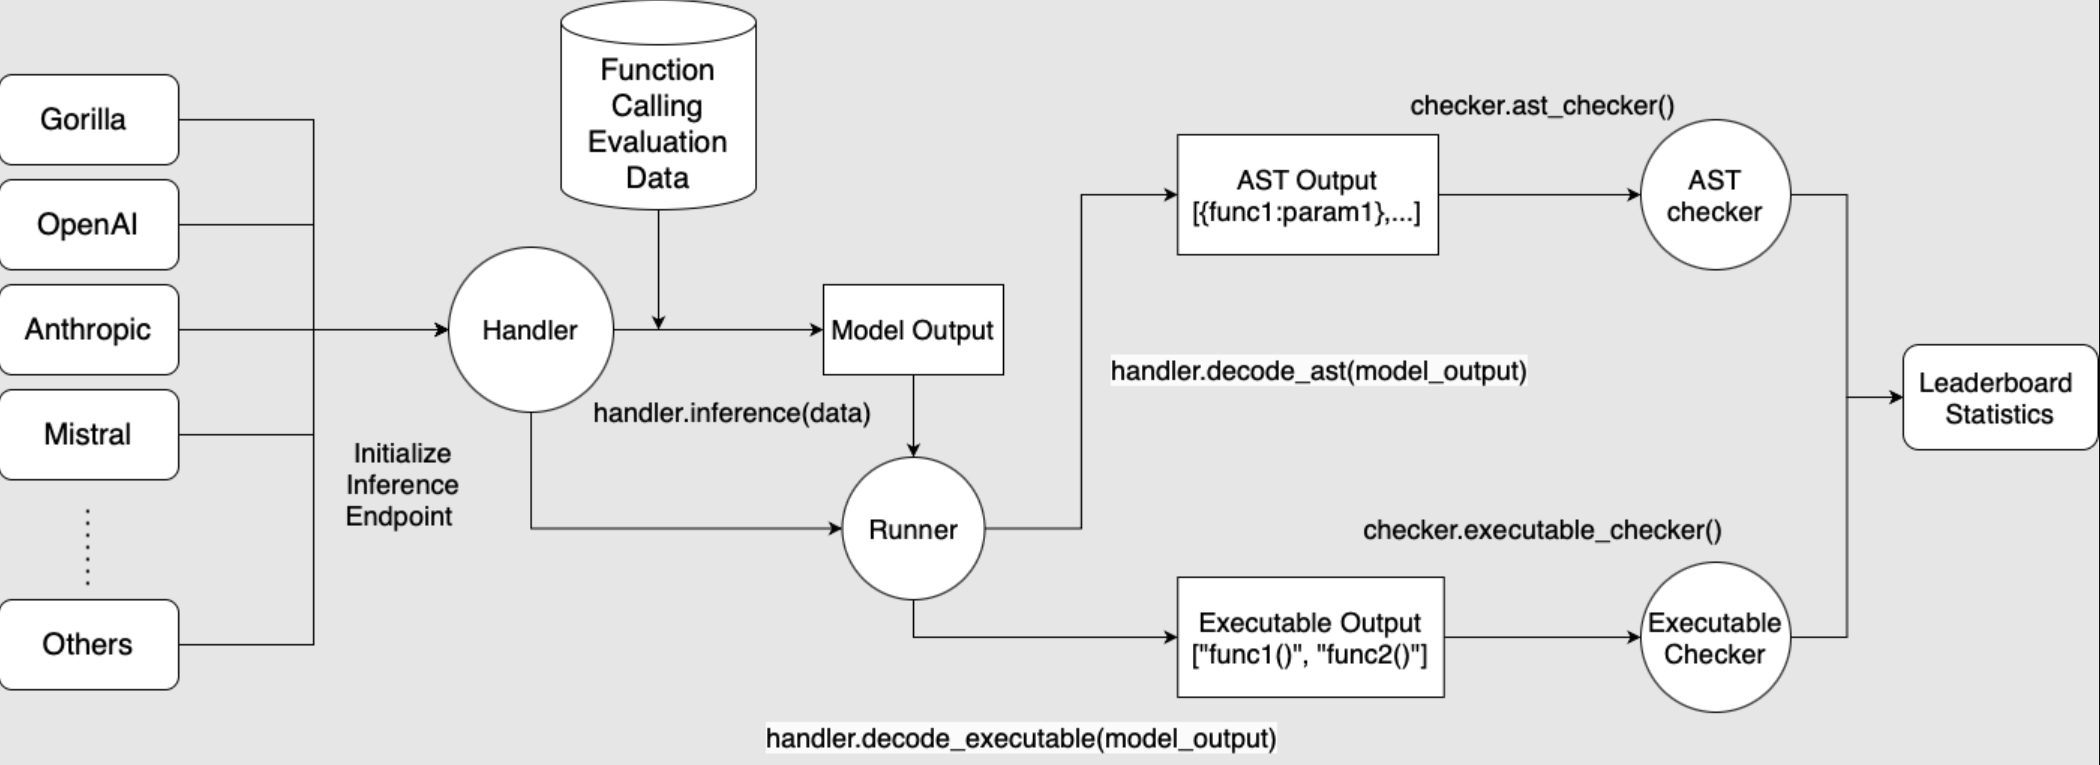

## τ-bench

> **Способ получения оценки**: датасет (с правильными состояниями среды), llm-as-a-judge.

> **Метрики**: Success Rate, Pass@k, Pass^k.

**τ-bench (tau-bench)** моделирует взаимодействие трёх сторон: пользователя, tool-using агента и программной среды. Агент ведёт многоходовый диалог, вызывает доменные API и должен одновременно выполнить просьбу пользователя и соблюдать правила компании.

Классические среды охватывают, например, розничную торговлю и авиаперевозки. Пользователь симулируется отдельной моделью и может сообщать данные постепенно, менять запрос или возражать. Состояние среды меняется после вызовов API, поэтому итог можно проверять по базе данных, а не только по красоте ответа.

Одна из важных идей - метрика **pass^k**: это вероятность того, что все из нескольких повторных запусков успешны. Она показывает надёжность лучше единичного удачного прогона; агент, который иногда решает задачу, но нестабилен, быстро теряет pass^k при увеличении k.

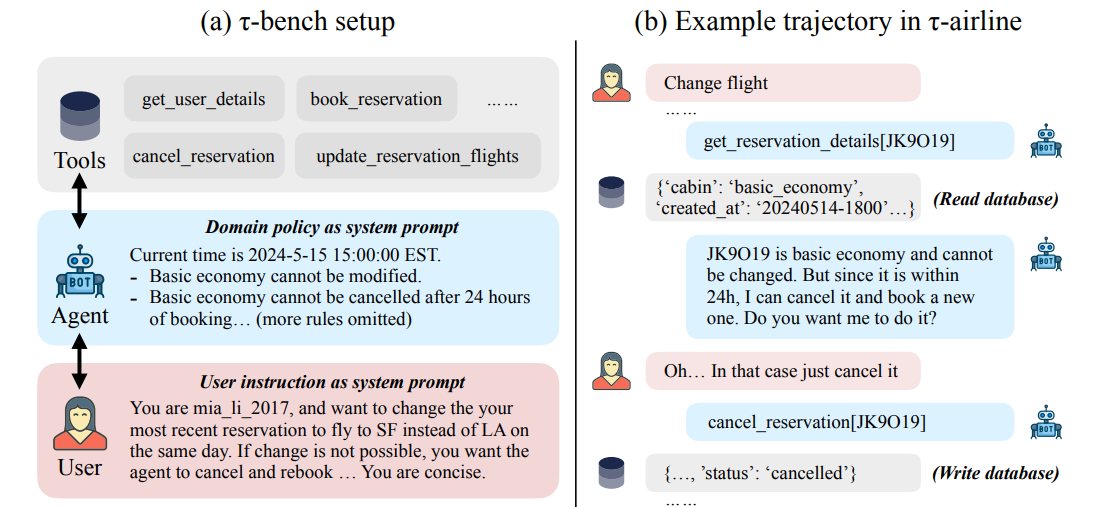

## Terminal-Bench

> **Способ получения оценки**: датасет (с автоматическими тестами).

> **Метрики**: Success Rate.

**Terminal-Bench** проверяет агентов на сложных задачах в командной строке: настройке программ, сборке проектов, обработке данных, обучении моделей, работе с серверами и т.д. Агент получает инструкцию и изолированное окружение (docker), после чего самостоятельно исследует его и выполняет команды.

Задача включает контейнерную среду, ограничение времени, автоматические тесты и эталонный ответ (при наличии). Проверяется **конечное состояние файлов и системы**, а не совпадение последовательности команд. Это допускает разные корректные стратегии и делает оценку ближе к инженерной работе. Terminal-Bench 2.x содержит трудные, вручную проверенные сценарии; официальный harness Harbor стандартизирует запуск разных агентов и журналирование.

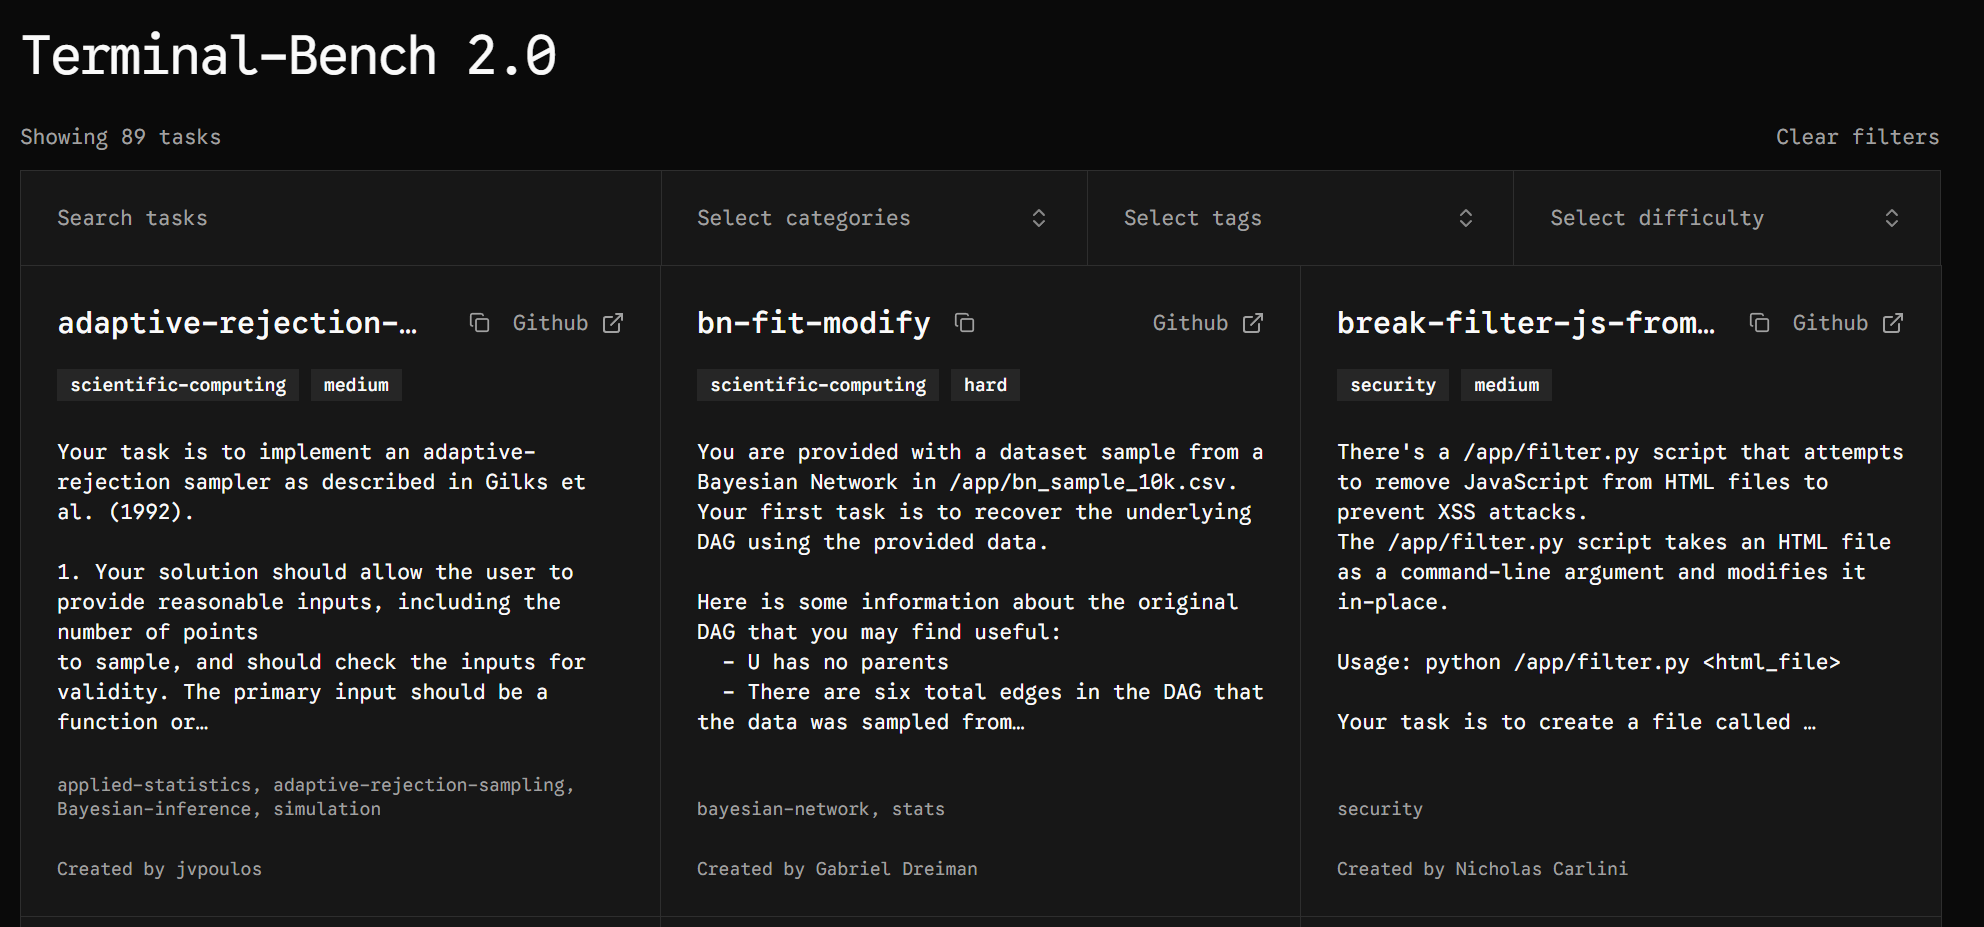

## OSWorld 2.0

> **Способ получения оценки**: датасет (с тестами и средами), llm-as-a-judge.

> **Метрики**: Success Rate, Task Completion Rate, PRM (Process Reward Model).


**OSWorld 2.0** - бенчмарк computer-use агентов на длинных рабочих процессах в реальных настольных приложениях. Агент взаимодействует с операционной системой через трансляцию экрана, мышь и клавиатуру

Вторая версия делает акцент на long-horizon workflow: задача состоит из нескольких зависимых этапов и может включать офисные приложения, браузер, файловую систему и профессиональные инструменты. Оценивание опирается на  **конечное состояние и промежуточные критерии**.

OSWorld 2.0 проверяет связку «модель + зрение + управление + harness».

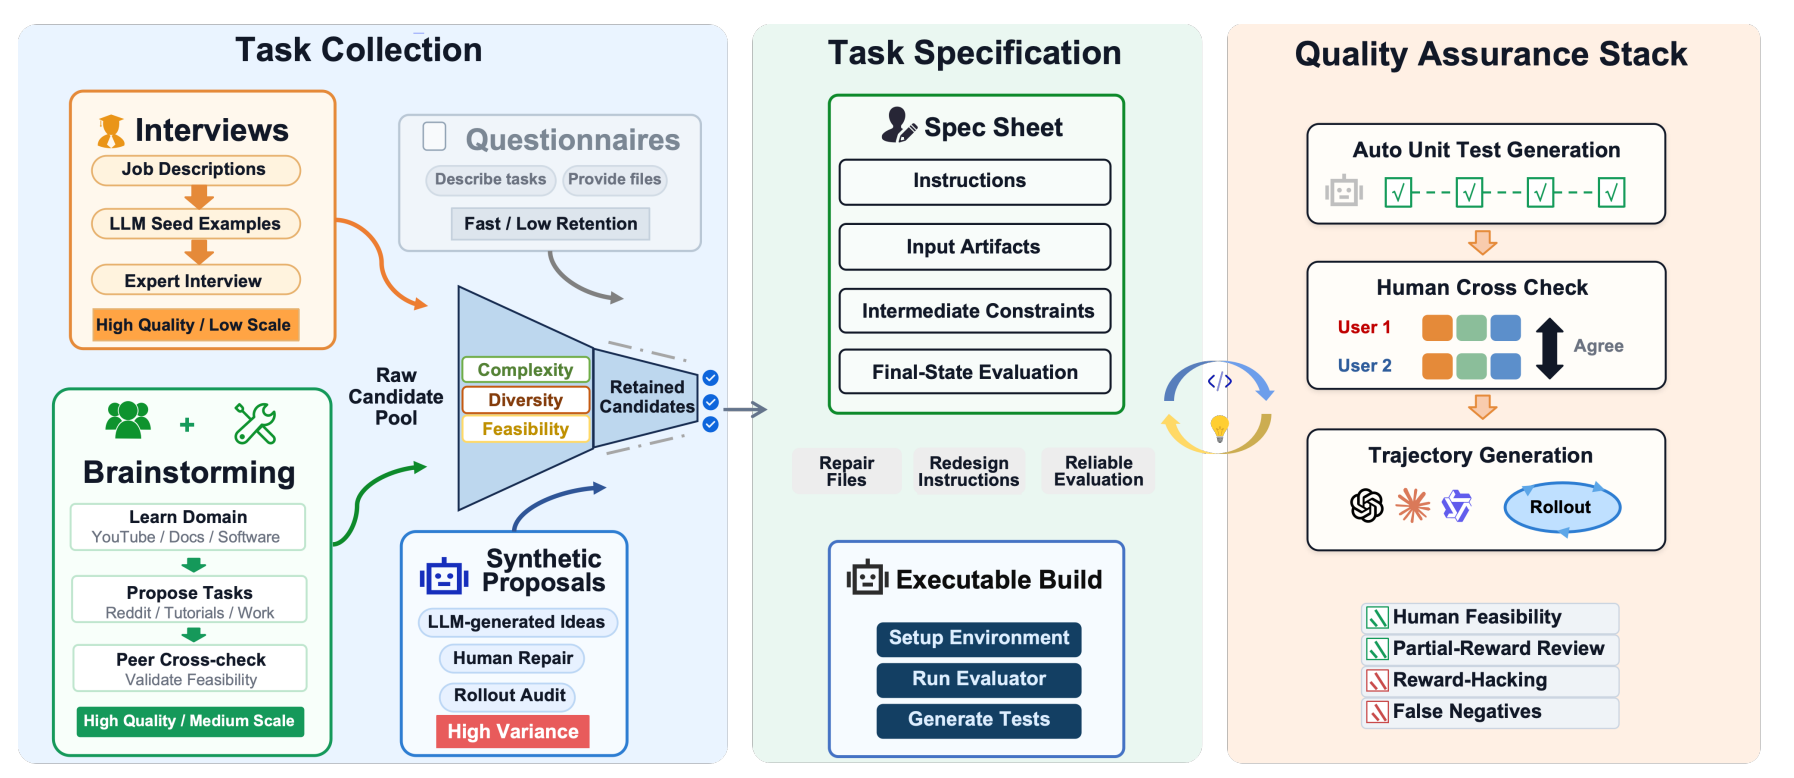

## Agents’ Last Exam

> **Способ получения оценки**: датасет (с тестами и средами), экспертная разметка.

> **Метрики**: Success Rate, Pass@k, PRM (Score).

**Agents’ Last Exam (ALE)** оценивает агентов на длинных и крайне сложных  профессиональных задачах с проверяемым результатом. Цель - выяснить, способен ли агент выполнить не искусственную задачу, а полноценный рабочий процесс и создать требуемый артефакт.

Задачи собираются совместно с отраслевыми экспертами и организованы по профессиональной таксономии. Они охватывают десятки поддоменов и разные классы цифровой работы. Выполнение проходит в воспроизводимых средах.

ALE публикует как полный pass rate, так и частичный score, так как агент может выполнить несколько критериев, но не получить полное решение. Разбиение по уровням сложности помогает отличать задачи, частично решаемые сегодня, от frontier-задач с длинным горизонтом и глубоким доменным знанием.


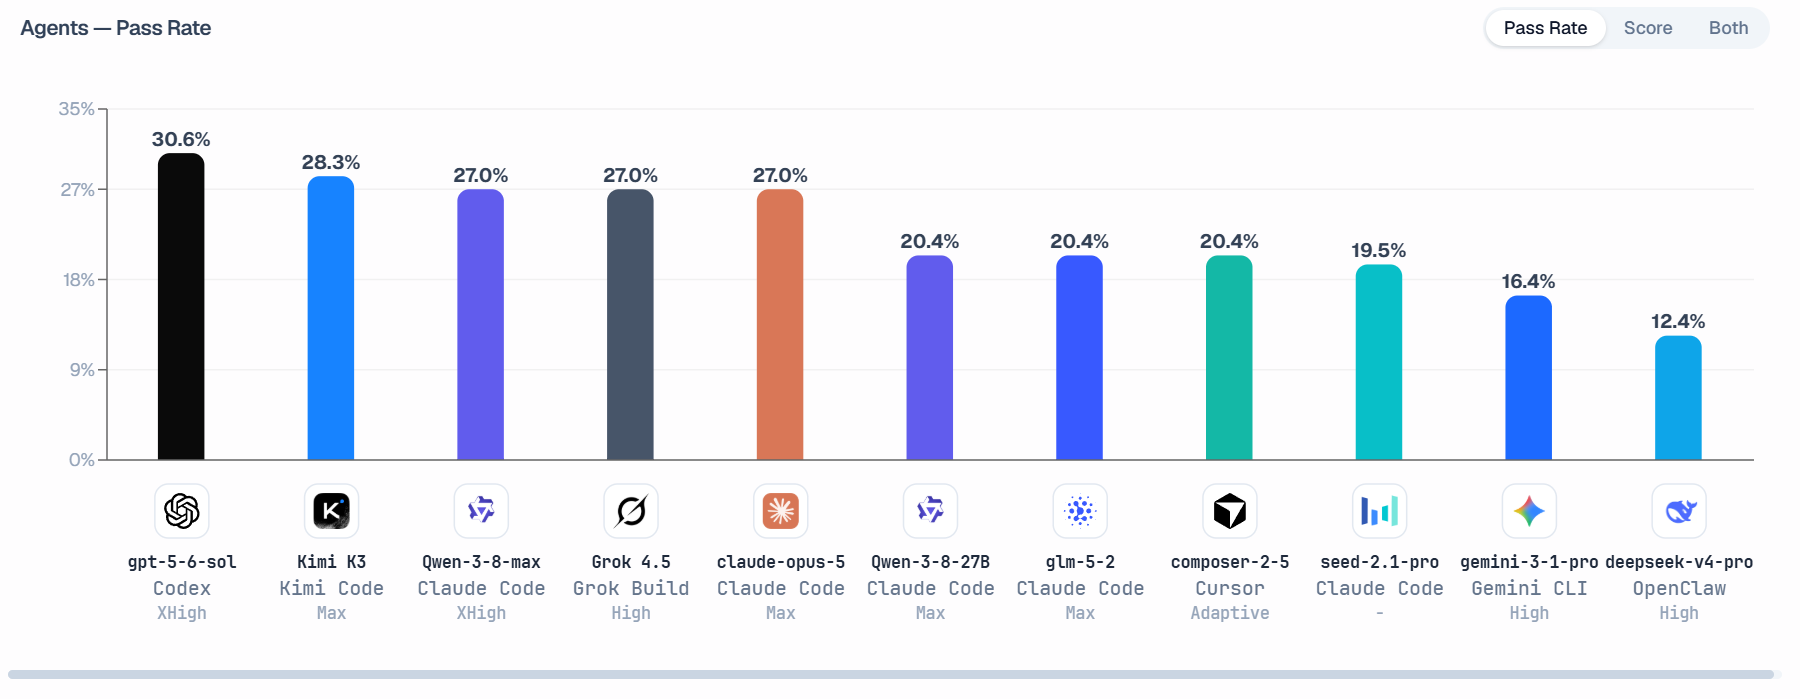

# Заключение

В этом уроке мы начали разговор о том, как правильно оценивать LLM-агентов. Примеры с кодом были намеренно упрощенными для того, чтобы охватить несколько метрик и методик получения оценок качества. В следующих уроках мы углубимся в вопрос оценивания domain-specific агентов и более подробно рассмотрим датасеты и judge.

# Итоги

На занятии мы:

- разделили эффективность, результативность и качество процесса;
- узнали, какие части агентной системы можно оценивать;
- рассмотрели методы получения оценок качества агента;
- рассчитали Success Rate, пошаговые оценки, Parameter Accuracy и метрики памяти;
- сравнили BFCL, τ-bench, Terminal-Bench, OSWorld 2.0 и Agents’ Last Exam.


# Полезные материалы

## Основы оценки агентов

1. [LangSmith: evaluation concepts](https://docs.langchain.com/langsmith/evaluation-concepts)
2. [LangGraph: Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
3. [G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment](https://arxiv.org/abs/2303.16634)
4. [Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena](https://arxiv.org/abs/2306.05685)

## Бенчмарки

1. [BFCL — официальный leaderboard и описание](https://gorilla.cs.berkeley.edu/leaderboard)
2. [τ-bench — статья](https://arxiv.org/abs/2406.12045)
3. [Terminal-Bench — официальный сайт](https://www.tbench.ai/)
4. [Terminal-Bench — репозиторий и harness](https://github.com/harbor-framework/terminal-bench)
5. [OSWorld 2.0 — статья](https://arxiv.org/abs/2606.29537)
6. [OSWorld-V2 — официальный репозиторий](https://github.com/xlang-ai/OSWorld-V2)
7. [Agents’ Last Exam — документация](https://agents-last-exam.org/docs/ale/index.html)
8. [Agents’ Last Exam — статья](https://arxiv.org/abs/2606.05405)

## Дополнительные материалы

1. [Process Reward Models That Think](https://arxiv.org/abs/2504.16828)
2. [OWASP Top 10 for LLM Applications](https://genai.owasp.org/llm-top-10/)
3. [NIST AI Risk Management Framework](https://www.nist.gov/itl/ai-risk-management-framework)